In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv("../data/processed/customer_support_tickets_en.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (16338, 7)


In [7]:
print("Available columns:")
print(df.columns.tolist())

print("Missing text:", df["text"].isna().sum())
print("Missing queue:", df["queue"].isna().sum())

Available columns:
['subject', 'body', 'queue', 'priority', 'type', 'text', 'clean_text']
Missing text: 0
Missing queue: 0


In [8]:
#Create modeling dataset
df_model = df.dropna(
    subset=["text", "queue"]
).copy()

df_model["text"] = df_model["text"].astype(str).str.strip()
df_model["queue"] = df_model["queue"].astype(str).str.strip()

df_model = df_model[
    (df_model["text"] != "") &
    (df_model["queue"] != "")
].copy()

df_model = df_model.reset_index(drop=True)

print("Modeling dataset shape:", df_model.shape)

Modeling dataset shape: (16338, 7)


In [20]:
#duplicate tickets
duplicate_count = df_model["text"].duplicated().sum()
print("Duplicate ticket texts:", duplicate_count)

print(
    "Remaining duplicate texts:",
    df_model["text"].duplicated().sum()
)


Duplicate ticket texts: 0
Remaining duplicate texts: 0


queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64


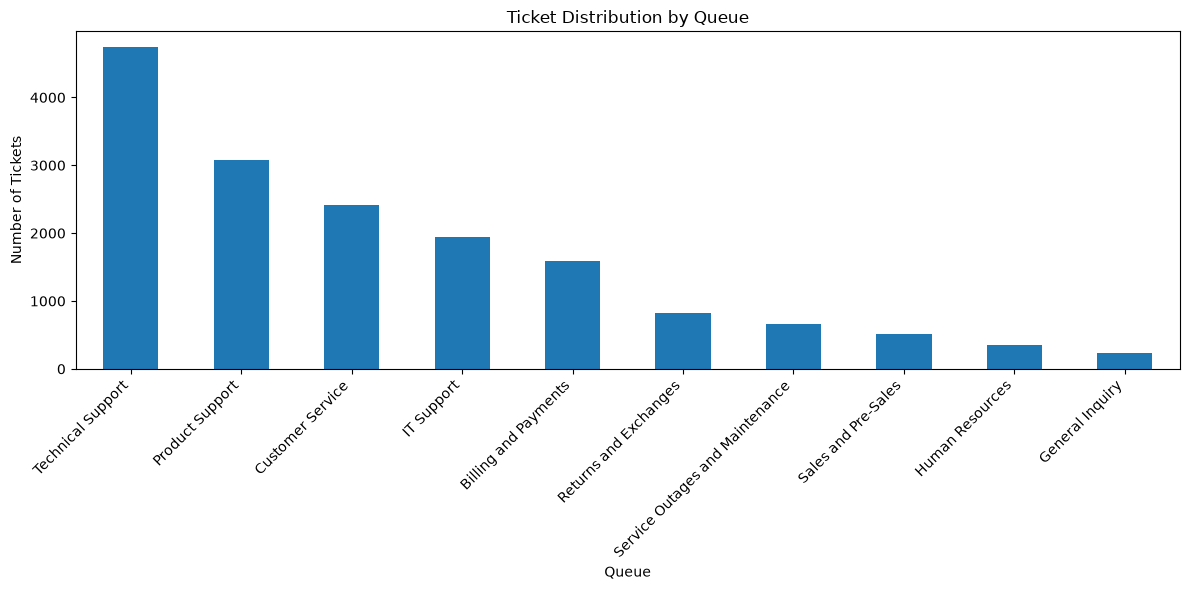

In [21]:
#queue distribution
queue_counts = df_model["queue"].value_counts()
print(queue_counts)

plt.figure(figsize=(12, 6))

queue_counts.plot(kind="bar")

plt.title("Ticket Distribution by Queue")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [22]:
#Define X and y
X = df_model["text"]
y = df_model["queue"]

print("Total samples:", len(X))
print("Number of queues:", y.nunique())

print("\nQueues:")
print(sorted(y.unique()))

Total samples: 16338
Number of queues: 10

Queues:
['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']


In [24]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

#check distribution
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 13070
Testing samples: 3268
Training distribution:
queue
Technical Support                  0.290
Product Support                    0.188
Customer Service                   0.148
IT Support                         0.119
Billing and Payments               0.098
Returns and Exchanges              0.050
Service Outages and Maintenance    0.041
Sales and Pre-Sales                0.031
Human Resources                    0.021
General Inquiry                    0.014
Name: proportion, dtype: float64

Testing distribution:
queue
Technical Support                  0.290
Product Support                    0.188
Customer Service                   0.147
IT Support                         0.119
Billing and Payments               0.098
Returns and Exchanges              0.050
Service Outages and Maintenance    0.041
Sales and Pre-Sales                0.032
Human Resources                    0.021
General Inquiry                    0.014
Name: proportion, dtype: float64


In [26]:
#save
os.makedirs("../data/splits", exist_ok=True)

train_df = pd.DataFrame({
    "text": X_train,
    "queue": y_train
})

test_df = pd.DataFrame({
    "text": X_test,
    "queue": y_test
})

train_df.to_csv(
    "../data/splits/train.csv",
    index=False
)

test_df.to_csv(
    "../data/splits/test.csv",
    index=False
)

print("Train and test datasets saved.")


Train and test datasets saved.


In [30]:
#TF-IDF model

tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Training TF-IDF shape: (13070, 46423)
Testing TF-IDF shape: (3268, 46423)
Number of TF-IDF features: 46423


In [32]:
#Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed.")

y_pred = logistic_model.predict(X_test_tfidf)
print("Predictions generated.")

Logistic Regression training completed.
Predictions generated.


In [33]:
#Evaluation
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.5294
Precision: 0.5424
Recall   : 0.5294
F1-score : 0.5306


In [ ]:
#Evaluation
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.5294
Precision: 0.5424
Recall   : 0.5294
F1-score : 0.5306


In [36]:
#classification report
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)
print(report)

                                 precision    recall  f1-score   support

           Billing and Payments       0.81      0.75      0.78       319
               Customer Service       0.45      0.46      0.45       482
                General Inquiry       0.44      0.64      0.52        47
                Human Resources       0.54      0.61      0.57        70
                     IT Support       0.42      0.50      0.46       388
                Product Support       0.50      0.42      0.46       615
          Returns and Exchanges       0.45      0.49      0.47       164
            Sales and Pre-Sales       0.36      0.70      0.47       103
Service Outages and Maintenance       0.59      0.80      0.68       133
              Technical Support       0.61      0.51      0.56       947

                       accuracy                           0.53      3268
                      macro avg       0.52      0.59      0.54      3268
                   weighted avg       0.54      0

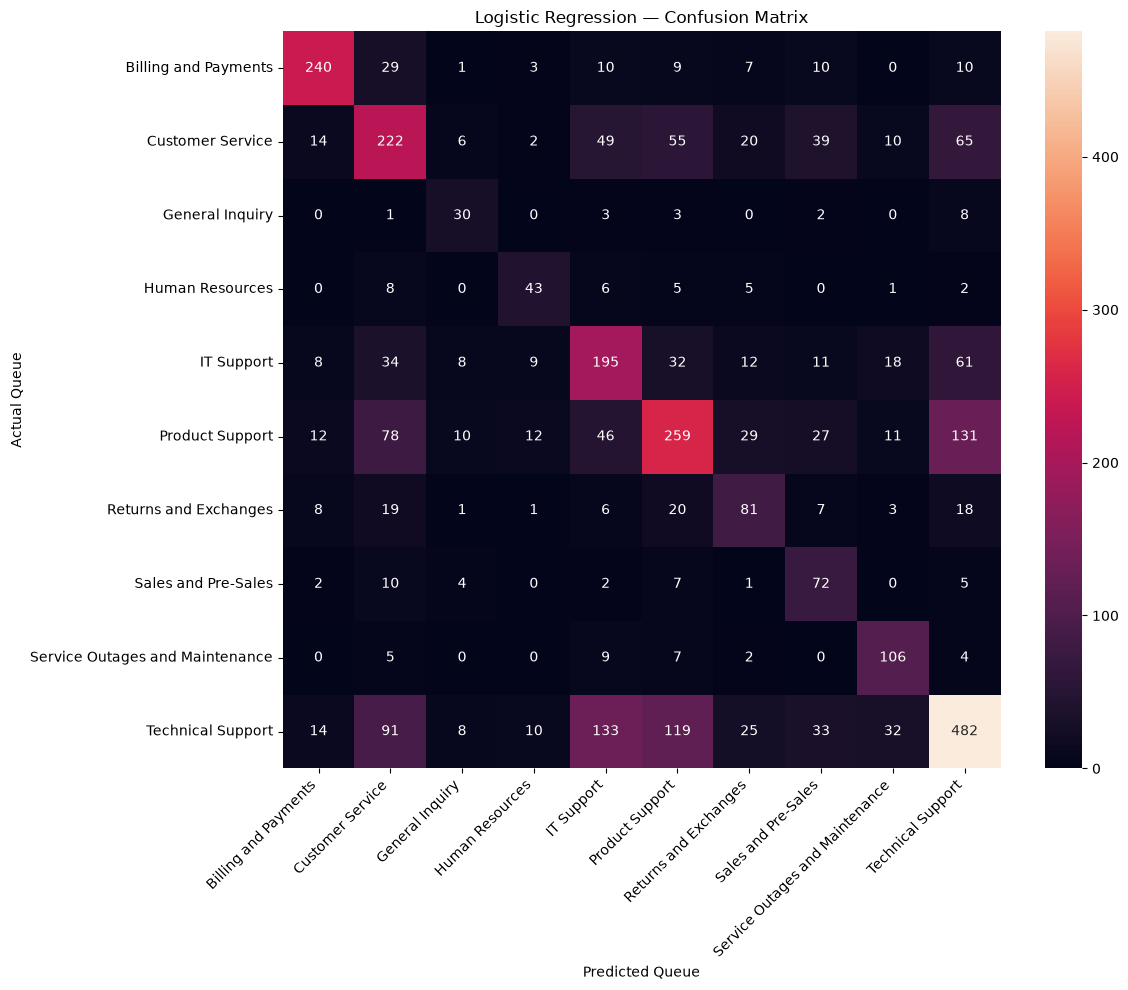

In [37]:
#Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=logistic_model.classes_
)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Queue")
plt.ylabel("Actual Queue")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
#Save evaluation results
results = pd.DataFrame([{
    "model": "Logistic Regression",
    "features": "TF-IDF",
    "accuracy": accuracy,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}])

os.makedirs("../reports", exist_ok=True)

results.to_csv(
    "../reports/model_results.csv",
    index=False
)

results

,model,features,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,TF-IDF,0.529376,0.542413,0.529376,0.530569


In [39]:
#Save model artifacts
os.makedirs("../models", exist_ok=True)
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)
joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)
print("TF-IDF vectorizer saved.")
print("Logistic Regression model saved.")

TF-IDF vectorizer saved.
Logistic Regression model saved.


TESTING
